# 1

## SGD с затухающей скоростью обучения (learning rate decay)
Модифицируйте базовый SGD, чтобы скорость обучения уменьшалась по формуле:

Используйте lr0=0.1, decay_rate=0.01.

Синтетические данные:
.

Начальные веса: w=5, b=5.

Требуется:

1. Сгенерировать данные согласно описанию

2. Реализовать указанную модификацию SGD

3. Обучить модель, вывести финальные параметры

4. Построить график сходимости

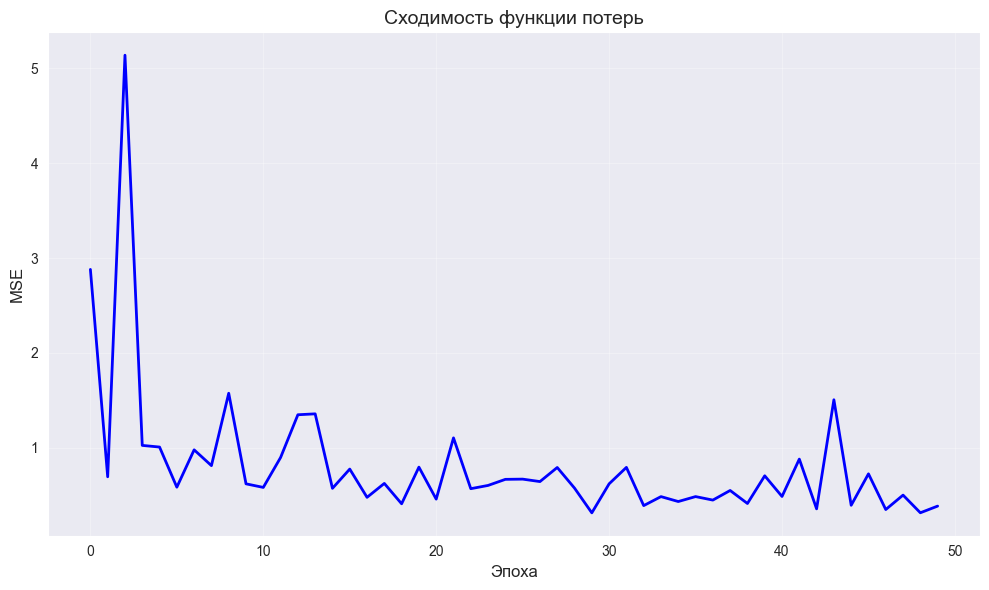

<Figure size 640x480 with 0 Axes>

Финальные параметры: w = -1.6814, b = 2.1367
Финальный loss: 0.383393


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 100
x = np.random.randn(n_samples) * 2
e = np.random.randn(n_samples) * 0.5
y_true = -1.5 * x + 2 + e


def sgd_with_decay(x, y, w_init, b_init, lr0=0.1, decay_rate=0.01, epochs=50):
    w, b = w_init, b_init
    n = len(x)

    w_history = [w]
    b_history = [b]
    loss_history = []
    lr_history = []

    for epoch in range(epochs):
        lr = lr0 / (1 + decay_rate * epoch)
        lr_history.append(lr)

        indices = np.random.permutation(n)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        epoch_loss = 0

        for i in range(n):
            y_pred = w * x_shuffled[i] + b

            dw = -2 * x_shuffled[i] * (y_shuffled[i] - y_pred)
            db = -2 * (y_shuffled[i] - y_pred)

            w -= lr * dw
            b -= lr * db

            epoch_loss += (y_shuffled[i] - y_pred) ** 2

        w_history.append(w)
        b_history.append(b)
        loss_history.append(epoch_loss / n)

    return w, b, w_history, b_history, loss_history, lr_history


w_init, b_init = 5.0, 5.0
w_final, b_final, w_history, b_history, loss_history, lr_history = sgd_with_decay(
    x, y_true, w_init, b_init, lr0=0.1, decay_rate=0.01, epochs=50
)


plt.figure(figsize=(10, 6))
plt.plot(loss_history, 'b-', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Сходимость функции потерь', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

print(f"Финальные параметры: w = {w_final:.4f}, b = {b_final:.4f}")
print(f"Финальный loss: {loss_history[-1]:.6f}")

# 2
## Персептрон для классификации ирисов (2 класса)

Загрузите датасет ирисов (sklearn.datasets.load_iris()). Возьмите только два класса (setosa и versicolor) и два признака (длина и ширина чашелистика). Обучите персептрон. Выведите веса и точность

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

mask = y < 2
X = X[mask][:, :2]
y = y[mask]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")

np.random.seed(42)

class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape


        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        for epoch in range(self.n_epochs):
            errors = 0
            epoch_loss = 0

            for idx in range(n_samples):
                linear_output = np.dot(X[idx], self.weights) + self.bias

                y_pred = self.activation(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * X[idx]
                self.bias += update

                if update != 0:
                    errors += 1

                epoch_loss += (y[idx] - y_pred) ** 2

            self.loss_history.append(epoch_loss / n_samples)

            if errors == 0:
                print(f"Сошлось на эпохе {epoch + 1}")
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(x) for x in linear_output])

perceptron = Perceptron(learning_rate=0.01, n_epochs=50)
perceptron.fit(X_train, y_train)

y_train_pred = perceptron.predict(X_train)
y_test_pred = perceptron.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("РЕЗУЛЬТАТЫ")
print(f"Веса: w1 (sepal length) = {perceptron.weights[0]:.4f}")
print(f"      w2 (sepal width)  = {perceptron.weights[1]:.4f}")
print(f"Смещение (bias): {perceptron.bias:.4f}")
print(f"\nТочность на обучающей выборке: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Точность на тестовой выборке:   {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Размер обучающей выборки: (70, 2)
Размер тестовой выборки: (30, 2)
Количество признаков: 2
РЕЗУЛЬТАТЫ
Веса: w1 (sepal length) = 0.3930
      w2 (sepal width)  = -0.5984
Смещение (bias): -0.2100

Точность на обучающей выборке: 0.9857 (98.57%)
Точность на тестовой выборке:   1.0000 (100.00%)


# 3
## Простая рекомендация на основе похожести пользователей
На основе user-item матрицы найдите для заданного пользователя топ-2 наиболее похожих пользователя (по косинусному сходству). Порекомендуйте целевому пользователю товар, который понравился похожим пользователям, но который он еще не оценивал. Реализуйте функцию recommend_for_user(user_id, user_item_matrix).

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def recommend_for_user_simple(user_id, user_item_matrix, top_n=2):
    similarities = cosine_similarity(user_item_matrix)
    sim_df = pd.DataFrame(similarities, index=user_item_matrix.index, columns=user_item_matrix.index)

    similar_users = sim_df[user_id].drop(user_id).nlargest(top_n)

    user_ratings = user_item_matrix.loc[user_id]
    rated_items = set(user_ratings[user_ratings > 0].index)

    similar_ratings = user_item_matrix.loc[similar_users.index]

    candidates = {}
    for item in user_item_matrix.columns:
        if item not in rated_items:
            item_ratings = similar_ratings[item]
            mask = item_ratings > 0
            if mask.any():
                weighted_score = np.average(
                    item_ratings[mask],
                    weights=similar_users[mask.index[mask]]
                )
                candidates[item] = weighted_score

    if candidates:
        best_item = max(candidates, key=candidates.get)
        return {
            'user_id': user_id,
            'similar_users': similar_users.to_dict(),
            'recommended_item': best_item,
            'score': candidates[best_item],
            'all_candidates': candidates
        }
    else:
        return {'user_id': user_id, 'recommended_item': None, 'message': 'Нет рекомендаций'}

if __name__ == "__main__":
    data = {
        'item_A': [5, 4, 1, 0, 5],
        'item_B': [3, 0, 1, 0, 2],
        'item_C': [0, 0, 0, 4, 0],
        'item_D': [1, 1, 5, 0, 0],
        'item_E': [4, 5, 0, 2, 4],
        'item_F': [0, 2, 4, 5, 1]
    }

    df = pd.DataFrame(data, index=['user_1', 'user_2', 'user_3', 'user_4', 'user_5'])

    result = recommend_for_user_simple('user_1', df)
    print(f"Результат: {result}")

Результат: {'user_id': 'user_1', 'similar_users': {'user_5': 0.9703621633430173, 'user_2': 0.8464861424907173}, 'recommended_item': 'item_F', 'score': np.float64(1.465909090909091), 'all_candidates': {'item_F': np.float64(1.465909090909091)}}


# 4

## Фильм: "Темный рыцарь" (The Dark Knight)
Используя предобученную модель для поиска ответов на вопросы (question-answering), извлеките информацию из краткого описания фильма. Для каждого вопроса программа должна найти фрагмент текста, содержащий ответ.

Модель: electra-base-squad2.

Вопросы: Кто злодей в фильме? Кто играет Бэтмена?

In [7]:
pip install tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 882.6 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.7 MB 882.6 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 907.1 kB/s eta 0:00:02
   ------------------------ --------------- 1.0/1.7 MB 949.8 kB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 972.7 kB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 987.0 kB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 985.7 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from transformers import pipeline


def recommend_movie_info():
    context = """
    The Dark Knight is a 2008 superhero film directed by Christopher Nolan.
    Christian Bale stars as Bruce Wayne / Batman, while Heath Ledger plays the Joker, the main villain.
    Aaron Eckhart portrays Harvey Dent, who becomes Two-Face. Michael Caine and Gary Oldman also star.
    The Joker, a criminal mastermind, seeks to create chaos in Gotham City and challenge Batman.
    """

    qa = pipeline("question-answering", model="deepset/electra-base-squad2")

    questions = [
        "Who is the villain?",
        "Who plays Batman?"
    ]

    for question in questions:
        result = qa(question=question, context=context)
        print(f"\nВопрос: {question}")
        print(f"Ответ: {result['answer']}")
        print(f"Уверенность: {result['score']:.3f}")

if __name__ == "__main__":
    recommend_movie_info()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu



Вопрос: Who is the villain?
Ответ: the Joker
Уверенность: 0.579

Вопрос: Who plays Batman?
Ответ: Christian Bale
Уверенность: 1.000


# 5

## Сравнение производительности GPU, TPU, NPU
Создайте классы GPU, TPU, NPU с атрибутами: количество ядер, тактовая частота, энергопотребление. Реализуйте метод compute, который вычисляет время выполнения операции свертки для заданного размера входных данных. Проведите сравнительный анализ для разных типов процессоров.

In [13]:
import numpy as np

class GPU:
    def __init__(self, name, cores, clock_freq, power_consumption):
        self.name = name
        self.cores = cores
        self.clock_freq = clock_freq  # в ГГц
        self.power_consumption = power_consumption  # в Вт
        self.type = "GPU"

    def compute(self, input_size):
        H, W, C = input_size
        kernel_size = 3

        out_H = H - kernel_size + 1
        out_W = W - kernel_size + 1
        out_elements = out_H * out_W

        ops_per_element = 2 * (kernel_size ** 2) * C
        total_ops = out_elements * ops_per_element

        ops_per_second = self.cores * self.clock_freq * 1e9

        time_ms = (total_ops / ops_per_second) * 1000

        return time_ms

class TPU:
    def __init__(self, name, cores, clock_freq, power_consumption):
        self.name = name
        self.cores = cores
        self.clock_freq = clock_freq
        self.power_consumption = power_consumption
        self.type = "TPU"

    def compute(self, input_size):
        H, W, C = input_size
        kernel_size = 3

        out_H = H - kernel_size + 1
        out_W = W - kernel_size + 1
        out_elements = out_H * out_W

        ops_per_element = 2 * (kernel_size ** 2) * C
        total_ops = out_elements * ops_per_element

        ops_per_second = self.cores * self.clock_freq * 1e9 * 2  # x2 эффективность

        time_ms = (total_ops / ops_per_second) * 1000
        return time_ms

class NPU:
    def __init__(self, name, cores, clock_freq, power_consumption):
        self.name = name
        self.cores = cores
        self.clock_freq = clock_freq
        self.power_consumption = power_consumption
        self.type = "NPU"

    def compute(self, input_size):
        H, W, C = input_size
        kernel_size = 3

        out_H = H - kernel_size + 1
        out_W = W - kernel_size + 1
        out_elements = out_H * out_W

        ops_per_element = 2 * (kernel_size ** 2) * C
        total_ops = out_elements * ops_per_element

        ops_per_second = self.cores * self.clock_freq * 1e9 * 1.5  # x1.5 эффективность

        time_ms = (total_ops / ops_per_second) * 1000
        return time_ms


def main():
    gpu = GPU("NVIDIA A100", cores=6912, clock_freq=1.41, power_consumption=250)
    tpu = TPU("Google TPU v4", cores=4, clock_freq=2.7, power_consumption=220)
    npu = NPU("Apple A16 Neural Engine", cores=16, clock_freq=1.5, power_consumption=5)

    test_sizes = [
        ("Маленькое (224x224)", (224, 224, 3)),
        ("Среднее (512x512)", (512, 512, 3)),
        ("Большое (1024x1024)", (1024, 1024, 3)),
    ]

    # Характеристики процессоров
    print("\nХАРАКТЕРИСТИКИ:")
    print(f"GPU: {gpu.name} | Ядер: {gpu.cores} | Частота: {gpu.clock_freq} ГГц | {gpu.power_consumption} Вт")
    print(f"TPU: {tpu.name} | Ядер: {tpu.cores} | Частота: {tpu.clock_freq} ГГц | {tpu.power_consumption} Вт")
    print(f"NPU: {npu.name} | Ядер: {npu.cores} | Частота: {npu.clock_freq} ГГц | {npu.power_consumption} Вт")

    print(f"{'Разрешение':<20} {'GPU':<15} {'TPU':<15} {'NPU':<15}")

    for desc, size in test_sizes:
        gpu_time = gpu.compute(size)
        tpu_time = tpu.compute(size)
        npu_time = npu.compute(size)

        print(f"{desc:<20} {gpu_time:<15.2f} {tpu_time:<15.2f} {npu_time:<15.2f}")


if __name__ == "__main__":
    main()


ХАРАКТЕРИСТИКИ:
GPU: NVIDIA A100 | Ядер: 6912 | Частота: 1.41 ГГц | 250 Вт
TPU: Google TPU v4 | Ядер: 4 | Частота: 2.7 ГГц | 220 Вт
NPU: Apple A16 Neural Engine | Ядер: 16 | Частота: 1.5 ГГц | 5 Вт
Разрешение           GPU             TPU             NPU            
Маленькое (224x224)  0.00            0.12            0.07           
Среднее (512x512)    0.00            0.65            0.39           
Большое (1024x1024)  0.01            2.61            1.57           


# 6
## Сеть из двух LIF-нейронов с возбуждающей связью
Создайте сеть из двух LIF-нейронов, где первый нейрон (пресинаптический) соединен со вторым (постсинаптическим) возбуждающим синапсом с фиксированным весом. Подайте на первый нейрон импульсный ток. Зафиксируйте и визуализируйте мембранные потенциалы обоих нейронов, а также моменты спайков. Покажите, как спайк первого нейрона влияет на потенциал второго.


Параметры симуляции:
  Длительность: 100 мс
  Шаг по времени: 0.1 мс
  Стимулирующий ток: 2.8 нА с 20 по 50 мс
  Вес синапса: 0.8
  Задержка синапса: 2.0 мс


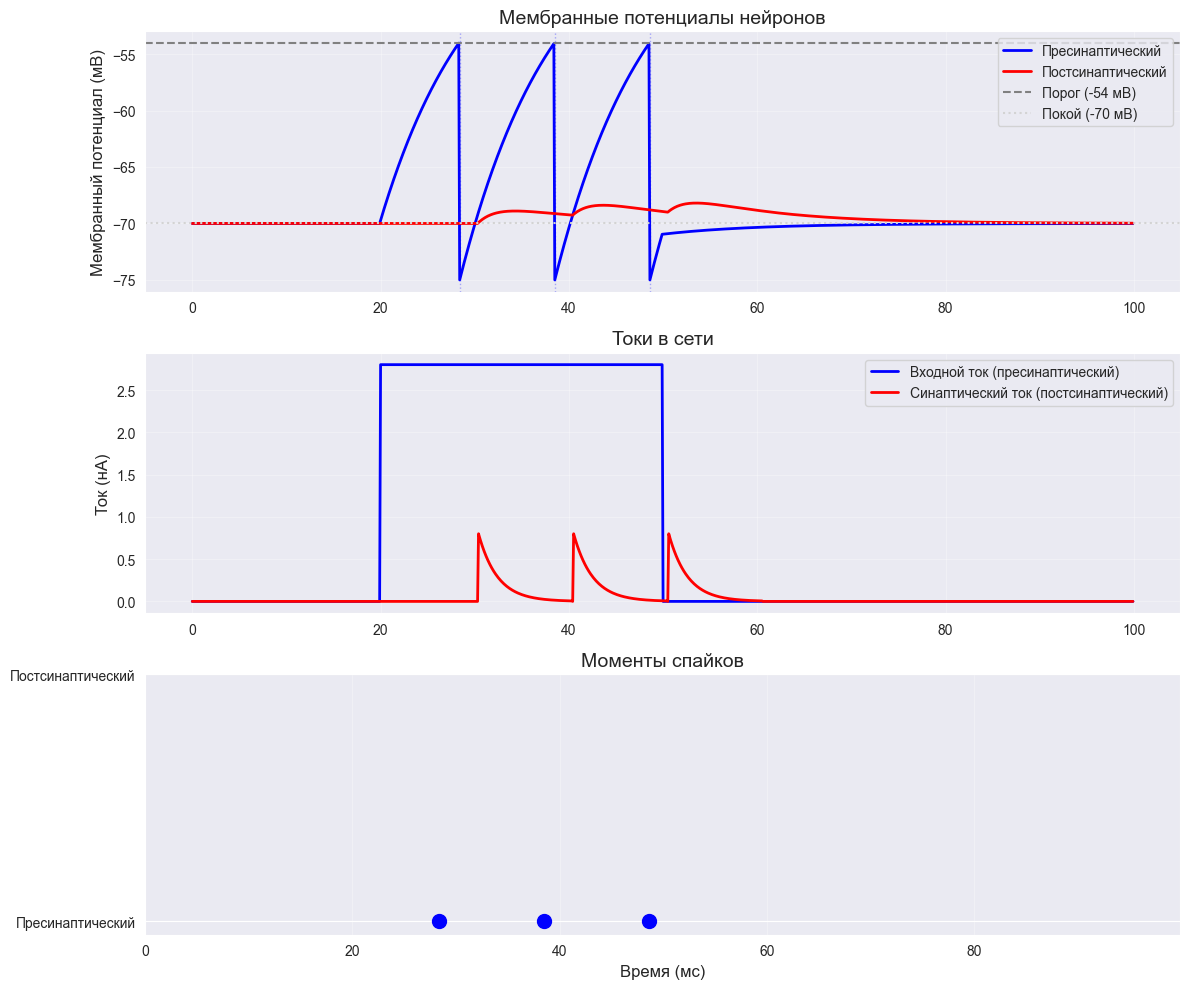

In [16]:
import numpy as np
import matplotlib.pyplot as plt

class LIFNeuron:
    def __init__(self, name, V_rest=-70, V_reset=-75, V_thresh=-55, R=10, tau=10, dt=0.1):
        self.name = name
        self.V_rest = V_rest
        self.V_reset = V_reset
        self.V_thresh = V_thresh
        self.R = R
        self.tau = tau
        self.dt = dt

        # Состояние нейрона
        self.V = V_rest
        self.spike_times = []
        self.V_history = []
        self.t_history = []

    def reset(self):
        self.V = self.V_rest
        self.spike_times = []
        self.V_history = []
        self.t_history = []

    def update(self, I_input, t, external_input=False):

        dv = (-(self.V - self.V_rest) + self.R * I_input) / self.tau
        self.V += dv * self.dt

        spiked = False
        if self.V >= self.V_thresh:
            self.V = self.V_reset
            self.spike_times.append(t)
            spiked = True

        self.V_history.append(self.V)
        self.t_history.append(t)

        return spiked


class Synapse:

    def __init__(self, weight, delay=1.0, tau_syn=2.0):
        self.weight = weight
        self.delay = delay
        self.tau_syn = tau_syn
        self.spike_buffer = []

    def propagate(self, pre_spike_time):

        arrival_time = pre_spike_time + self.delay
        self.spike_buffer.append(arrival_time)

    def get_input(self, t_current):
        I_syn = 0
        self.spike_buffer = [t for t in self.spike_buffer if t > t_current - 5 * self.tau_syn]

        for spike_time in self.spike_buffer:
            if spike_time <= t_current:
                I_syn += self.weight * np.exp(-(t_current - spike_time) / self.tau_syn)

        return I_syn


def simulate_network(duration=100, dt=0.1, I_amp=2.5, I_start=20, I_duration=5):
    pre_neuron = LIFNeuron("Пресинаптический", V_rest=-70, V_reset=-75, V_thresh=-54)
    post_neuron = LIFNeuron("Постсинаптический", V_rest=-70, V_reset=-75, V_thresh=-54)

    synapse = Synapse(weight=0.8, delay=2.0, tau_syn=2.0)

    t = np.arange(0, duration, dt)

    I_pre_hist = []
    I_syn_hist = []

    for t_current in t:
        if I_start <= t_current < I_start + I_duration:
            I_pre = I_amp
        else:
            I_pre = 0

        pre_spiked = pre_neuron.update(I_pre, t_current, external_input=True)

        if pre_spiked:
            synapse.propagate(t_current)

        I_syn = synapse.get_input(t_current)

        post_neuron.update(I_syn, t_current, external_input=False)

        I_pre_hist.append(I_pre)
        I_syn_hist.append(I_syn)

    return t, pre_neuron, post_neuron, I_pre_hist, I_syn_hist


def plot_results(t, pre_neuron, post_neuron, I_pre_hist, I_syn_hist):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    ax1 = axes[0]
    ax1.plot(t, pre_neuron.V_history, 'b-', linewidth=2, label='Пресинаптический')
    ax1.plot(t, post_neuron.V_history, 'r-', linewidth=2, label='Постсинаптический')

    ax1.axhline(y=pre_neuron.V_thresh, color='gray', linestyle='--',
                label=f'Порог ({pre_neuron.V_thresh} мВ)')
    ax1.axhline(y=pre_neuron.V_rest, color='lightgray', linestyle=':',
                label=f'Покой ({pre_neuron.V_rest} мВ)')

    for spike_time in pre_neuron.spike_times:
        ax1.axvline(x=spike_time, color='blue', alpha=0.3, linestyle=':', linewidth=1)
    for spike_time in post_neuron.spike_times:
        ax1.axvline(x=spike_time, color='red', alpha=0.3, linestyle=':', linewidth=1)

    ax1.set_ylabel('Мембранный потенциал (мВ)', fontsize=12)
    ax1.set_title('Мембранные потенциалы нейронов', fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(t, I_pre_hist, 'b-', linewidth=2, label='Входной ток (пресинаптический)')
    ax2.plot(t, I_syn_hist, 'r-', linewidth=2, label='Синаптический ток (постсинаптический)')

    ax2.set_ylabel('Ток (нА)', fontsize=12)
    ax2.set_title('Токи в сети', fontsize=14)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[2]

    for spike_time in pre_neuron.spike_times:
        ax3.plot(spike_time, 1, 'bo', markersize=10)

    for spike_time in post_neuron.spike_times:
        ax3.plot(spike_time, 2, 'ro', markersize=10)

    ax3.set_yticks([1, 2])
    ax3.set_yticklabels(['Пресинаптический', 'Постсинаптический'])
    ax3.set_xlabel('Время (мс)', fontsize=12)
    ax3.set_title('Моменты спайков', fontsize=14)
    ax3.set_xlim([t[0], t[-1]])
    ax3.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()


def main():
    duration = 100
    dt = 0.1
    I_amp = 2.8
    I_start = 20
    I_duration = 30

    print(f"\nПараметры симуляции:")
    print(f"  Длительность: {duration} мс")
    print(f"  Шаг по времени: {dt} мс")
    print(f"  Стимулирующий ток: {I_amp} нА с {I_start} по {I_start+I_duration} мс")
    print(f"  Вес синапса: 0.8")
    print(f"  Задержка синапса: 2.0 мс")

    t, pre_neuron, post_neuron, I_pre_hist, I_syn_hist = simulate_network(
        duration=duration,
        dt=dt,
        I_amp=I_amp,
        I_start=I_start,
        I_duration=I_duration
    )

    plot_results(t, pre_neuron, post_neuron, I_pre_hist, I_syn_hist)


if __name__ == "__main__":
    main()

# 7

## Создание текстового описания изображения
Используйте модель для генерации подписей к изображениям (например, BLIP или ViT-GPT2). Загрузите несколько изображений и сгенерируйте для каждого текстовое описание.

config.json: 0.00B [00:00, ?B/s]

C:\Users\Hierarchy\PycharmProjects\labs\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hierarchy\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\Hierarchy\PycharmProjects\labs\.venv\Lib\site-packages\transformers\mode

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


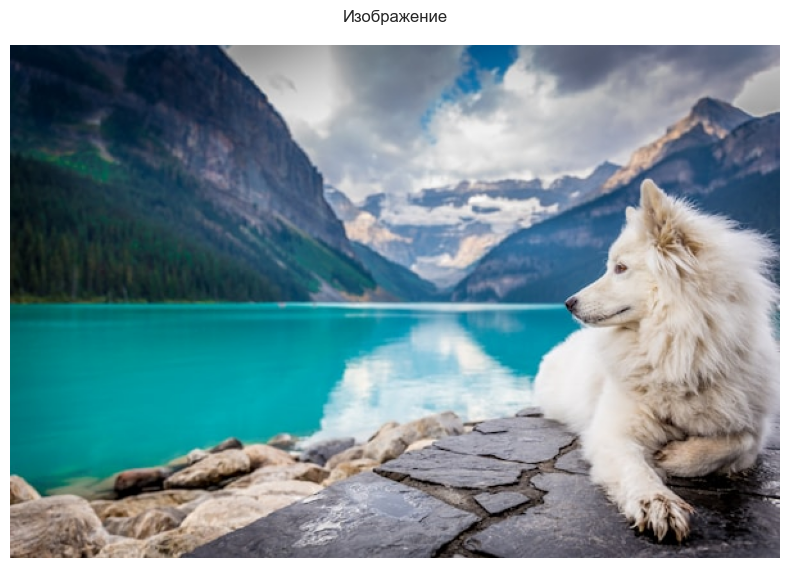

URL: https://images.unsplash.com/photo-1504208434309-cb...
Подпись: a white dog sitting on a rock near a lake



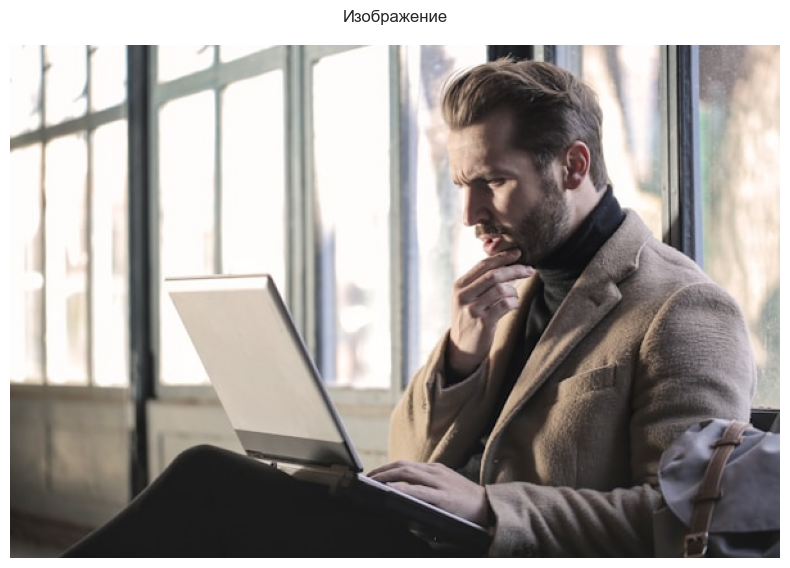

URL: https://images.unsplash.com/photo-1518644730709-08...
Подпись: a man sitting on a bench using his laptop



In [19]:
from transformers import pipeline
import requests
from PIL import Image

captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")

image_urls = [
    "https://images.unsplash.com/photo-1504208434309-cb69f4fe52b0?w=600",
    "https://images.unsplash.com/photo-1518644730709-0835105d9daa?w=600",
]

def display_image(url, title="Изображение"):
    image = Image.open(requests.get(url, stream=True).raw).convert('RGB')

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"{title}\n", fontsize=12, wrap=True)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for url in image_urls:
    display_image(url)
    result = captioner(url)
    print(f"URL: {url[:50]}...")
    print(f"Подпись: {result[0]['generated_text']}\n")


# 8

## Квантование модели с TensorFlow Lite
Возьмите простую модель Keras (например, для классификации MNIST). Сконвертируйте ее в формат TensorFlow Lite с применением квантования. Сравните размер файла и время инференса до и после квантования.

In [21]:
import shutil
import tensorflow as tf
import numpy as np
import time
import os
from tensorflow import keras

if os.path.exists('mnist_model'):
    shutil.rmtree('mnist_model')

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

model = keras.Sequential([
    keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(16, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=0)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Точность оригинальной модели: {test_acc:.4f}")

model.save('mnist_model', save_format='tf')
original_size = get_folder_size('mnist_model')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

with open('mnist_model_quantized.tflite', 'wb') as f:
    f.write(tflite_quantized_model)

quantized_size = os.path.getsize('mnist_model_quantized.tflite') / (1024 * 1024)

def benchmark_original(model, x_test, runs=50):
    start = time.time()
    for i in range(runs):
        _ = model.predict(x_test[i:i+1], verbose=0)
    return (time.time() - start) * 1000 / runs

def benchmark_tflite(model_path, x_test, runs=50):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()

    interpreter.set_tensor(input_details[0]['index'], x_test[0:1].astype(np.float32))
    interpreter.invoke()

    times = []
    for i in range(runs):
        interpreter.set_tensor(input_details[0]['index'], x_test[i:i+1].astype(np.float32))
        start = time.time()
        interpreter.invoke()
        times.append((time.time() - start) * 1000)

    return np.mean(times)

original_time = benchmark_original(model, x_test)
quantized_time = benchmark_tflite('mnist_model_quantized.tflite', x_test)

print("Вывод")
print(f"{'Размер (MB)':<20} {original_size:<20.2f} {quantized_size:<20.2f}")
print(f"{'Инференс (мс)':<20} {original_time:<20.3f} {quantized_time:<20.3f}")

Точность оригинальной модели: 0.9745
INFO:tensorflow:Assets written to: mnist_model\assets


INFO:tensorflow:Assets written to: mnist_model\assets


INFO:tensorflow:Assets written to: C:\Users\HIERAR~1\AppData\Local\Temp\tmpecyvhqk5\assets


INFO:tensorflow:Assets written to: C:\Users\HIERAR~1\AppData\Local\Temp\tmpecyvhqk5\assets


Вывод
Размер (MB)          0.32                 0.02                
Инференс (мс)        80.428               0.041               


C:\Users\Hierarchy\PycharmProjects\labs\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
